In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/churn-bigml.csv")

df_cluster = df.drop('Churn', axis=1)

df_cluster = pd.get_dummies(df_cluster, drop_first=True)

scaler = StandardScaler()
X = scaler.fit_transform(df_cluster)


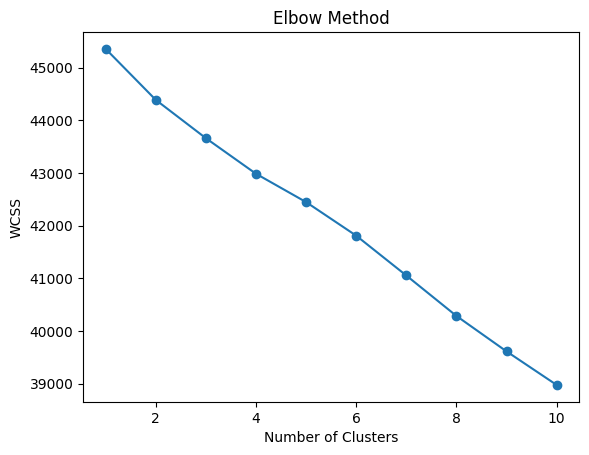

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [4]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

df['KMeans_Cluster'] = kmeans_labels
df.head()


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,...,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,KMeans_Cluster
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,...,29.89,215.8,90,9.71,8.7,4,2.35,1,False,0
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,...,19.42,208.8,111,9.40,12.7,6,3.43,4,True,0
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,...,27.01,160.6,128,7.23,5.4,9,1.46,4,True,2
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,...,11.67,189.6,105,8.53,7.7,6,2.08,2,False,1
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,...,18.28,178.7,90,8.04,11.1,1,3.00,1,False,1


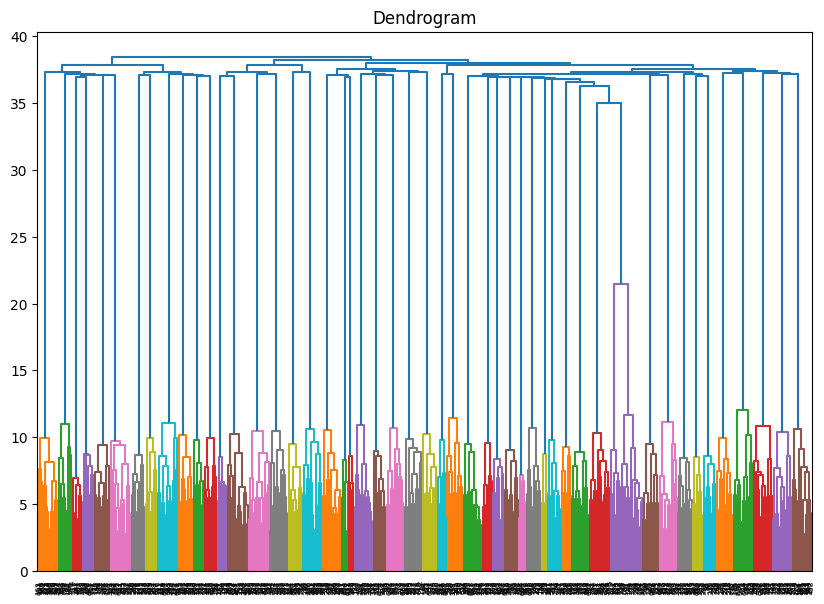

In [5]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10,7))
sch.dendrogram(sch.linkage(X, method='ward'))
plt.title("Dendrogram")
plt.show()


In [6]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc.fit_predict(X)

df['Hierarchical_Cluster'] = hc_labels


In [7]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

df['DBSCAN_Cluster'] = dbscan_labels


In [8]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X)

df['GMM_Cluster'] = gmm_labels


In [ ]:
from sklearn.metrics import silhouette_score

print("KMeans Silhouette Score:", silhouette_score(X, kmeans_labels))
print("Hierarchical Silhouette Score:", silhouette_score(X, hc_labels))

if len(set(dbscan_labels)) > 1:
    print("DBSCAN Silhouette Score:", silhouette_score(X, dbscan_labels))

print("GMM Silhouette Score:", silhouette_score(X, gmm_labels))


KMeans Silhouette Score: 0.018980911059228122
Hierarchical Silhouette Score: 0.014461287023404394
GMM Silhouette Score: 0.023399516308656856


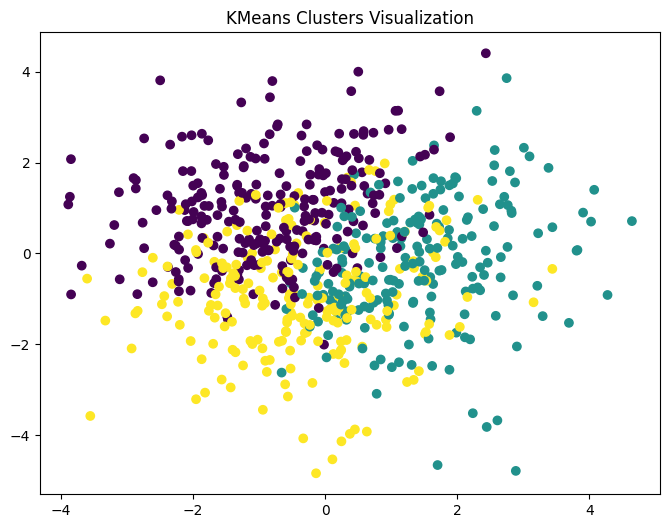

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, cmap='viridis')
plt.title("KMeans Clusters Visualization")
plt.show()


In [11]:
df.head()
df.to_csv("churn_clustered_output.csv", index=False)
